In [10]:
import os
import torch
from datasets import load_dataset, load_from_disk
import numpy as np
import matplotlib.pyplot as plt
from transformers import (
    EncoderDecoderModel,
    EncoderDecoderConfig,
    BertConfig,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    EarlyStoppingCallback
)
import evaluate

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Split, ByteLevel, Whitespace, Metaspace
from tokenizers.decoders import ByteLevel as ByteLevelDecoder
from tokenizers.normalizers import NFKC, Sequence

bleu = evaluate.load("sacrebleu")

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")




Is CUDA available? True
Device Name: NVIDIA A100-PCIE-40GB


In [11]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [ ]:
PAIR = "si-ta"
SRC_LANG = "si"
TGT_LANG = "ta"

MAX_LEN = 128
PAD_ID = 0
UNK_ID = 1
BOS_ID = 2
EOS_ID = 3

VOCAB_SIZE_SI = 32000
VOCAB_SIZE_TA = 32000



In [ ]:
sys.path.insert(0, os.path.abspath("../../"))
from custom_tokenizers.SuperGPETokenizer import SuperGPETokenizer

print("Loading tokenizers...")
tokenizer_src = SuperGPETokenizer(vocab_size=32000)
tokenizer_src.load("../../tokenizers_trained/sgpe_si_1m_32k")

tokenizer_tgt = SuperGPETokenizer(vocab_size=32000)
tokenizer_tgt.load("../../tokenizers_trained/sgpe_ta_227k_32k")




Loading tokenizers...


In [14]:
# =========================
# MODEL
# =========================

def build_model():

    encoder_config = BertConfig(
        vocab_size=VOCAB_SIZE_SI,
        hidden_size=512,
        num_hidden_layers=6,
        num_attention_heads=8,
        intermediate_size=2048,
        max_position_embeddings=512,
        pad_token_id=PAD_ID,
    )

    decoder_config = BertConfig(
        vocab_size=VOCAB_SIZE_TA,
        hidden_size=512,
        num_hidden_layers=6,
        num_attention_heads=8,
        intermediate_size=2048,
        max_position_embeddings=512,
        is_decoder=True,
        add_cross_attention=True,
        pad_token_id=PAD_ID,
    )

    config = EncoderDecoderConfig.from_encoder_decoder_configs(
        encoder_config, decoder_config
    )

    config.decoder_start_token_id = BOS_ID
    config.bos_token_id = BOS_ID
    config.pad_token_id = PAD_ID
    config.eos_token_id = EOS_ID
    #config.forced_eos_token_id = EOS_ID
    #outdated
    #config.max_length = MAX_LEN
    #config.num_beams = 4
    #config.early_stopping = True

    #check these settings, as they can cause issues if not set correctly
    config.tie_encoder_decoder = False
    config.tie_word_embeddings = False

    model = EncoderDecoderModel(config)

    model.generation_config.max_length = MAX_LEN
    model.generation_config.num_beams = 4
    model.generation_config.early_stopping = True

    return model


# =========================
# DATASET PREPROCESS
# =========================

def preprocess(example):

    src = example["translation"][SRC_LANG]
    tgt = example["translation"][TGT_LANG]

    src_ids = tokenizer_src.encode(src).ids[:MAX_LEN-2]
    tgt_ids = tokenizer_tgt.encode(tgt).ids[:MAX_LEN-2]

    src_ids = [BOS_ID] + src_ids + [EOS_ID]
    tgt_ids = [BOS_ID] + tgt_ids + [EOS_ID]

    return {
        "input_ids": src_ids,
        "labels": tgt_ids
    }


def collate_fn(batch):

    input_ids = [torch.tensor(x["input_ids"]) for x in batch]
    labels = [torch.tensor(x["labels"]) for x in batch]

    input_ids = torch.nn.utils.rnn.pad_sequence(
        input_ids, batch_first=True, padding_value=PAD_ID
    )

    labels = torch.nn.utils.rnn.pad_sequence(
        labels, batch_first=True, padding_value=-100    #check if -100 is the correct padding value for labels in seq2seq models
    )

    # Create decoder_input_ids (The "Shift Right" fix)
    decoder_input_ids = labels.new_zeros(labels.shape)
    decoder_input_ids[:, 1:] = labels[:, :-1].clone()
    decoder_input_ids[:, 0] = BOS_ID
    decoder_input_ids.masked_fill_(decoder_input_ids == -100, PAD_ID)
    # While optional in some versions, it's best practice to provide this
    decoder_attention_mask = (decoder_input_ids != PAD_ID).long()

    attention_mask = (input_ids != PAD_ID).long()

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "decoder_input_ids": decoder_input_ids,
        "decoder_attention_mask": decoder_attention_mask,
        "labels": labels
    }


def compute_metrics(eval_preds):

    preds, labels = eval_preds

    # In case the model returns more than the prediction logits
    if isinstance(preds, tuple):
        preds = preds[0]

    # Replace -100 in labels so we can decode them
    labels = np.where(labels != -100, labels, PAD_ID)

    decoded_preds = [
        tokenizer_tgt.decode(p, skip_special_tokens=True)
        for p in preds
    ]

    decoded_labels = [
        tokenizer_tgt.decode(l, skip_special_tokens=True)
        for l in labels
    ]

    # Some simple post-processing
    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [[label.strip()] for label in decoded_labels]

    result = bleu.compute(
        predictions=decoded_preds,
        references=decoded_labels
    )

    return {"bleu": result["score"]}




In [15]:
# =========================
# MAIN
# =========================

print("Loading dataset...")
#dataset = load_dataset("Helsinki-NLP/opus-100", PAIR, cache_dir="./hf_cache")
dataset = load_from_disk("../../hf_cache/TamSiPara")



Loading dataset...


In [16]:
print("Preprocessing dataset...")
dataset = dataset.map(preprocess, remove_columns=dataset["train"].column_names, num_proc=8)

#DEBUG: Create a tiny slice of the data
#small_train_dataset = dataset["train"].select(range(100))
#small_eval_dataset = dataset["validation"].select(range(50))




Preprocessing dataset...


In [ ]:
print("Building model...")
model = build_model()

print("creating training arguments...")
training_args = Seq2SeqTrainingArguments(

    output_dir="./sin_ta_sin_sgpe_32k_ta_sgpe_32k/checkpoints",
    save_total_limit=2,
    metric_for_best_model="bleu",
    greater_is_better=True,
    load_best_model_at_end=True,

    per_device_train_batch_size=320,
    per_device_eval_batch_size=320,
    gradient_accumulation_steps = 1,

    num_train_epochs=20,

    learning_rate=3e-4,

    #warmup_steps=1000,
    warmup_ratio = 0.1,

    max_grad_norm=1.0,

    bf16=True,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=100,

    #label_smoothing_factor=0.1,

    predict_with_generate=True,

    push_to_hub=False,

    report_to="none"
)

print("Creating trainer...")
trainer = Seq2SeqTrainer(

    model=model,

    args=training_args,

    train_dataset=dataset["train"],
    #train_dataset=small_train_dataset,

    eval_dataset=dataset["validation"],
    #eval_dataset=small_eval_dataset,

    data_collator=collate_fn,

    compute_metrics=compute_metrics,

    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)


Building model...


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


creating training arguments...
Creating trainer...


In [ ]:
#trainer.train(resume_from_checkpoint=True)
trainer.train()

print("Saving final model...")
trainer.save_model("./sin_ta_sin_sgpe_32k_ta_sgpe_32k/final_translation_model")

Epoch,Training Loss,Validation Loss,Bleu
1,6.736016,2.944368,0.000000
2,2.959013,2.139729,0.046580
3,1.882911,1.674792,0.189049
4,1.638396,1.472602,0.924246
5,1.494844,1.363843,1.109092
6,1.307369,1.299184,1.757586
7,1.234604,1.241395,2.039571
8,1.179103,1.209872,2.462904
9,1.068009,1.178602,2.389209
10,1.034835,1.156545,2.572716


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


...

That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['decoder.cls.predictions.decoder.weight', 'decoder.cls.predictions.decoder.bias'].


Saving final model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

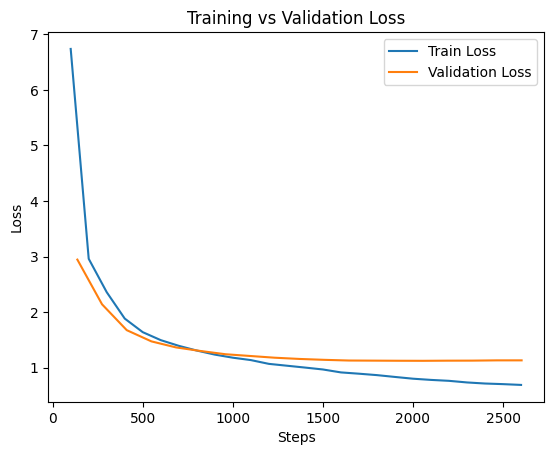

In [24]:
log_history = trainer.state.log_history

train_steps = []
train_loss = []

eval_steps = []
eval_loss = []

for log in log_history:
    if "loss" in log and "epoch" in log:
        train_steps.append(log["step"])
        train_loss.append(log["loss"])
    
    if "eval_loss" in log:
        eval_steps.append(log["step"])
        eval_loss.append(log["eval_loss"])


plt.figure()

plt.plot(train_steps, train_loss, label="Train Loss")
plt.plot(eval_steps, eval_loss, label="Validation Loss")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [25]:
# test_results = trainer.evaluate(dataset["test"])
# print(test_results)

In [26]:
torch.no_grad()
model.eval()

EncoderDecoderModel(
  (encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 512, padding_idx=0)
      (position_embeddings): Embedding(512, 512)
      (token_type_embeddings): Embedding(2, 512)
      (LayerNorm): LayerNorm((512,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=512, out_features=512, bias=True)
              (key): Linear(in_features=512, out_features=512, bias=True)
              (value): Linear(in_features=512, out_features=512, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=512, out_features=512, bias=True)
              (LayerNorm): LayerNorm((512,), eps=1e-12, elementw

In [27]:
import time
from torch.utils.data import DataLoader

def evaluate_inference(model, dataset, batch_size=64):

    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        num_workers=4,
        pin_memory=True
    )

    all_preds = []
    all_labels = []

    total_tokens = 0
    total_samples = 0

    start_time = time.time()

    with torch.no_grad():
        for batch in dataloader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"]

            outputs = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=MAX_LEN,
                num_beams=4
            )

            # Count tokens (generated)
            total_tokens += outputs.numel()
            total_samples += input_ids.size(0)

            # Move to CPU
            outputs = outputs.cpu().numpy()
            labels = labels.numpy()

            labels = np.where(labels != -100, labels, PAD_ID)

            decoded_preds = [
                tokenizer_tgt.decode(p, skip_special_tokens=True)
                for p in outputs
            ]

            decoded_labels = [
                tokenizer_tgt.decode(l, skip_special_tokens=True)
                for l in labels
            ]

            all_preds.extend([p.strip() for p in decoded_preds])
            all_labels.extend([[l.strip()] for l in decoded_labels])

    end_time = time.time()

    total_time = end_time - start_time

    # 🔥 Speed metrics
    samples_per_sec = total_samples / total_time
    tokens_per_sec = total_tokens / total_time

    # 📊 BLEU
    bleu_score = bleu.compute(
        predictions=all_preds,
        references=all_labels
    )["score"]

    return {
        "bleu": bleu_score,
        "samples_per_sec": samples_per_sec,
        "tokens_per_sec": tokens_per_sec,
        "total_time_sec": total_time
    }

In [23]:
results = evaluate_inference(model, dataset["test"], batch_size=64)
print(results)

That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


{'bleu': 3.527511106249496, 'samples_per_sec': 55.61805613680212, 'tokens_per_sec': 6370.714622133863, 'total_time_sec': 35.95954513549805}
